## ODS Newton's method and steepest descent.ipynb

<ipython-input-1-0962e265a5d5>:18: DeprecationWarning: scipy.misc.derivative is deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. You may consider using findiff: https://github.com/maroba/findiff or numdifftools: https://github.com/pbrod/numdifftools
  slope = derivative(f, x0, dx=1e-6)


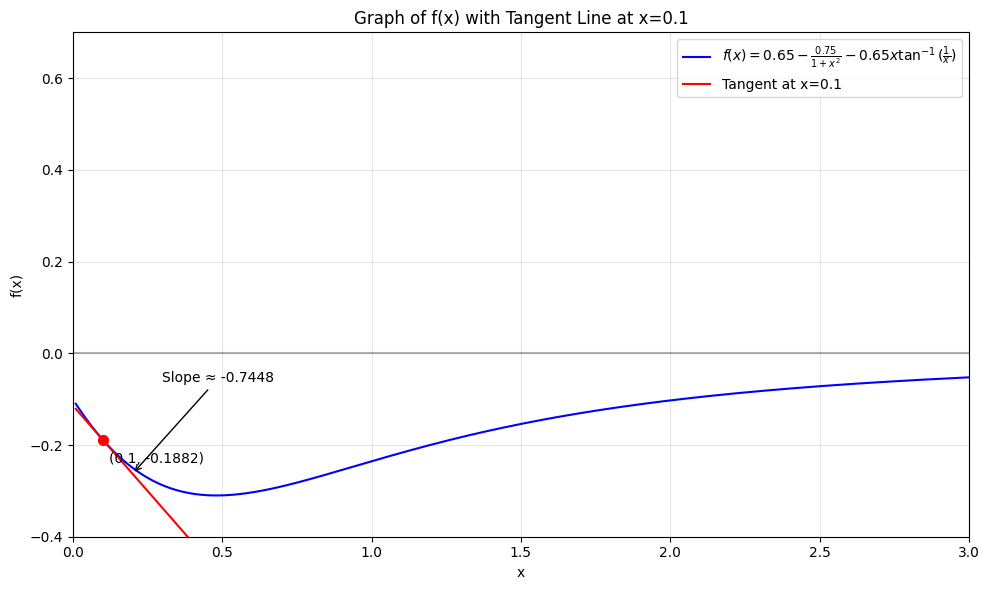

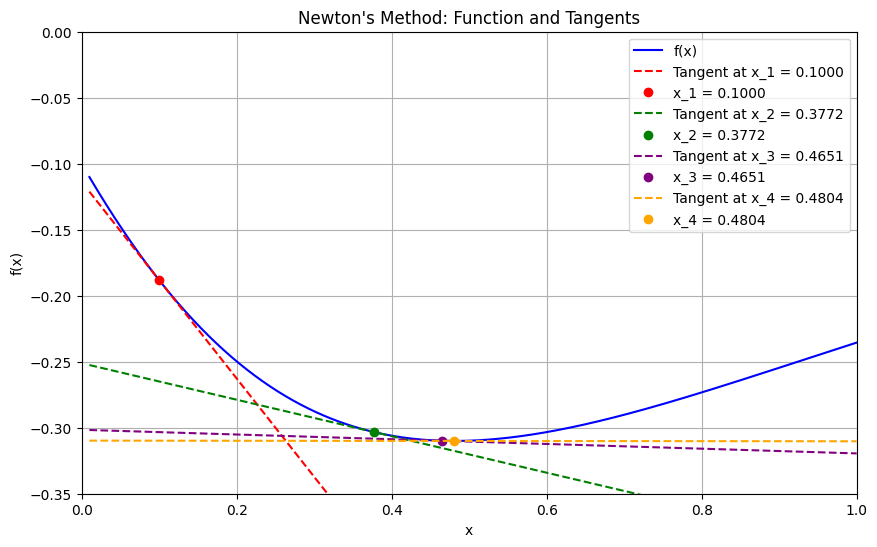

Newton's Method Iterations:
x_1 = 0.100000, f(x_1) = -0.188198
x_2 = 0.377240, f(x_2) = -0.303279
x_3 = 0.465120, f(x_3) = -0.309881
x_4 = 0.480409, f(x_4) = -0.310020
x_5 = 0.480864, f(x_5) = -0.310021


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function f(x)
def f(x):
    return 0.65 - 0.75 / (1 + x**2) - 0.65 * x * np.arctan(1 / x)

# Define the first derivative f'(x)
def f_prime(x):
    return (1.5 * x) / (1 + x**2)**2 - 0.65 * np.arctan(1 / x) + (0.65 * x) / (x**2 + 1)

# Define the second derivative f''(x)
def f_double_prime(x):
    term1 = (1.5 - 3 * x**2 - 4.5 * x**4) / (1 + x**2)**4
    term2 = 0.65 / (x**2 + 1)
    term3 = (0.65 - 0.65 * x**2) / (x**2 + 1)**2
    return term1 + term2 + term3

# Newton's method iteration
def newton_step(x_n):
    return x_n - f_prime(x_n) / f_double_prime(x_n)

# Tangent line function: y = f(x_n) + f'(x_n) * (x - x_n)
def tangent_line(x, x_n):
    return f(x_n) + f_prime(x_n) * (x - x_n)

# Parameters
x_start = 0.1  # Starting point
epsilon = 0.01  # Convergence criterion
max_iterations = 10  # Limit iterations

# Perform Newton's method and store points
x_values = [x_start]
for i in range(max_iterations):
    x_new = newton_step(x_values[-1])
    x_values.append(x_new)
    if abs(x_new - x_values[-2]) < epsilon:
        break

# Define x range for plotting
x = np.linspace(0.01, 1, 1000)  # Avoid x = 0 to prevent division by zero

# Compute function values
y = f(x)

# Plot the function
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='f(x)', color='blue')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

# Plot tangents at each iteration
colors = ['red', 'green', 'purple', 'orange']  # Colors for each tangent
x_tangent = np.linspace(0.01, 1, 100)  # Range for tangent lines

for i, x_n in enumerate(x_values[:-1]):  # Exclude the last point for clarity
    y_tangent = tangent_line(x_tangent, x_n)
    plt.plot(x_tangent, y_tangent, label=f'Tangent at x_{i+1} = {x_n:.4f}',
             color=colors[i % len(colors)], linestyle='--')
    plt.plot(x_n, f(x_n), 'o', color=colors[i % len(colors)],
             label=f'x_{i+1} = {x_n:.4f}')

# Customize the plot
plt.title("Newton's Method: Function and Tangents")
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.ylim(-0.35, 0)  # Adjust y-limits to focus on the minimum
plt.xlim(0, 1)      # Focus on positive x near the minimum

# Show the plot
plt.show()

# Print iteration results
print("Newton's Method Iterations:")
for i, x_n in enumerate(x_values):
    print(f"x_{i+1} = {x_n:.6f}, f(x_{i+1}) = {f(x_n):.6f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the function f(x, y, z) = 2x^2 + 2xy + z + 3y^2
def f(x, y, z):
    return 2*x**2 + 2*x*y + z + 3*y**2

# Calculate gradient (partial derivatives)
def gradient(x, y, z):
    df_dx = 4*x + 2*y  # ∂f/∂x
    df_dy = 2*x + 6*y  # ∂f/∂y
    df_dz = 1          # ∂f/∂z
    return np.array([df_dx, df_dy, df_dz])

# Calculate Hessian (second derivatives matrix)
def hessian(x, y, z):
    return np.array([
        [4, 2, 0],  # ∂²f/∂x², ∂²f/∂x∂y, ∂²f/∂x∂z
        [2, 6, 0],  # ∂²f/∂y∂x, ∂²f/∂y², ∂²f/∂y∂z
        [0, 0, 0]   # ∂²f/∂z∂x, ∂²f/∂z∂y, ∂²f/∂z²
    ])

# Initial point
x0 = np.array([1, -2, 3])

# Newton's method - one iteration
def newton_iteration(x):
    grad = gradient(x[0], x[1], x[2])
    hess = hessian(x[0], x[1], x[2])
    # Solve Hessian * delta = -gradient for delta
    delta = np.linalg.solve(hess, -grad)
    return x + delta

# Steepest descent - one iteration (using small step size 0.1)
def steepest_descent_iteration(x):
    grad = gradient(x[0], x[1], x[2])
    # Move in opposite direction of gradient with step size 0.1
    return x - 0.1 * grad

# Perform one iteration for both methods
newton_result = newton_iteration(x0)

# Create 3D plot
fig = plt.figure(figsize=(12, 8))

# Create surface plot of the function (showing x, y plane with z)
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = f(X, Y, 3)  # Fix z at initial value 3 for visualization

# Plot the surface
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.5)
ax.scatter([x0[0]], [x0[1]], [f(x0[0], x0[1], x0[2])], color='red', s=100, label='Initial point')
ax.scatter([newton_result[0]], [newton_result[1]], [f(newton_result[0], newton_result[1], newton_result[2])],
          color='blue', s=100, label="Newton's method")
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(x,y,z)')
ax.set_title('Newton\'s Method Iteration')
ax.legend()

# Print results for comparison
print("Initial point (x, y, z):", x0)
print("After Newton's method (x, y, z):", newton_result)
print("Function value at Newton's point:", f(newton_result[0], newton_result[1], newton_result[2]))

LinAlgError: Singular matrix

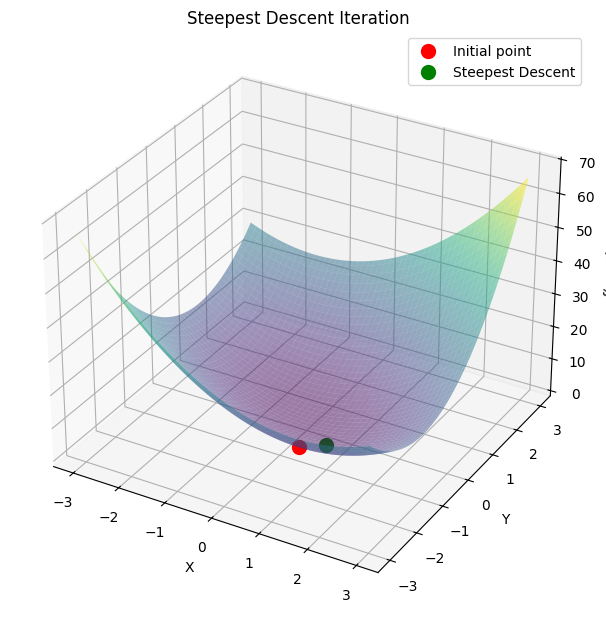

After Steepest Descent (x, y, z): [ 1.  -1.   2.9]
Function value at Steepest Descent point: 5.9


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the function f(x, y, z) = 2x^2 + 2xy + z + 3y^2
def f(x, y, z):
    return 2*x**2 + 2*x*y + z + 3*y**2

# Calculate gradient (partial derivatives)
def gradient(x, y, z):
    df_dx = 4*x + 2*y  # ∂f/∂x
    df_dy = 2*x + 6*y  # ∂f/∂y
    df_dz = 1          # ∂f/∂z
    return np.array([df_dx, df_dy, df_dz])

# Calculate Hessian (second derivatives matrix)
def hessian(x, y, z):
    return np.array([
        [4, 2, 0],  # ∂²f/∂x², ∂²f/∂x∂y, ∂²f/∂x∂z
        [2, 6, 0],  # ∂²f/∂y∂x, ∂²f/∂y², ∂²f/∂y∂z
        [0, 0, 0]   # ∂²f/∂z∂x, ∂²f/∂z∂y, ∂²f/∂z²
    ])

# Initial point
x0 = np.array([1, -2, 3])

# Steepest descent - one iteration (using small step size 0.1)
def steepest_descent_iteration(x):
    grad = gradient(x[0], x[1], x[2])
    # Move in opposite direction of gradient with step size 0.1
    return x - 0.1 * grad

# Perform one iteration for both methods
steepest_result = steepest_descent_iteration(x0)

# Create 3D plot
fig = plt.figure(figsize=(12, 8))

# Create surface plot of the function (showing x, y plane with z)
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = f(X, Y, 3)  # Fix z at initial value 3 for visualization

# Plot for Steepest Descent
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='viridis', alpha=0.5)
ax2.scatter([x0[0]], [x0[1]], [f(x0[0], x0[1], x0[2])], color='red', s=100, label='Initial point')
ax2.scatter([steepest_result[0]], [steepest_result[1]], [f(steepest_result[0], steepest_result[1], steepest_result[2])],
           color='green', s=100, label="Steepest Descent")
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('f(x,y,z)')
ax2.set_title('Steepest Descent Iteration')
ax2.legend()

plt.tight_layout()
plt.show()

print("After Steepest Descent (x, y, z):", steepest_result)
print("Function value at Steepest Descent point:", f(steepest_result[0], steepest_result[1], steepest_result[2]))